# Gradient Boosting Regression

**Course:** 23CSE301 Machine Learning — Capstone Project  
**Review:** Review 1  
**Track:** Regression  
**Dataset:** `diamonds_sampled.csv`

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
RANDOM_STATE=42
TEST_SIZE=0.20
TARGET="price"
DATA_FILENAME="diamonds_sampled.csv"
np.random.seed(RANDOM_STATE)

In [2]:
def resolve_file(filename):
    candidates=[Path("../data")/filename,Path("data")/filename,Path("/mnt/data")/filename,Path(filename)]
    for p in candidates:
        if p.exists(): return p
    raise FileNotFoundError(f"Could not find {filename}. Checked: {[str(p) for p in candidates]}")
DATA_PATH=resolve_file(DATA_FILENAME)
print("Using dataset:",DATA_PATH.resolve())

Using dataset: C:\Sem-5\ml\jyp_notebook\Reg_review1\diamonds_sampled.csv


In [3]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self,factor=1.5): self.factor=factor
    def fit(self,X,y=None):
        a=np.asarray(X,dtype=float); self.q1_=np.nanpercentile(a,25,axis=0); self.q3_=np.nanpercentile(a,75,axis=0); i=self.q3_-self.q1_; self.lower_=self.q1_-self.factor*i; self.upper_=self.q3_+self.factor*i; return self
    def transform(self,X): return np.clip(np.asarray(X,dtype=float),self.lower_,self.upper_)
    def get_feature_names_out(self,input_features=None):
        return np.asarray(input_features if input_features is not None else [f"x{i}" for i in range(len(self.lower_))],dtype=object)

## 1. Dataset loading & audit — A1

In [4]:
df=pd.read_csv(DATA_PATH)
print("Shape:",df.shape)
print("\nData types:"); display(df.dtypes.to_frame("dtype"))
print("\nMissing values:"); display(df.isnull().sum().to_frame("missing"))
print("\nDuplicate rows:",df.duplicated().sum())
print("\nTarget summary:"); display(df[TARGET].describe().to_frame("value"))
print("\nTarget unique values:",df[TARGET].nunique())
display(df.head())

Shape: (2100, 11)

Data types:


,dtype
id: 0,int64
carat,float64
cut,str
color,str
clarity,str
depth,float64
table,float64
price,int64
x,float64
y,float64



Missing values:


,missing
id: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0



Duplicate rows: 0

Target summary:


,value
count,2100.000000
mean,3971.387143
std,4124.225067
min,360.000000
25%,926.750000
50%,2324.500000
75%,5357.250000
max,18803.000000



Target unique values: 1623


,id: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1389,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,50053,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,41646,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,42378,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,17245,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


### A1 observation — student interpretation required

Use the actual output above to describe dataset size, feature types, missing values, duplicates, and target distribution. Use your own wording.

## 2. Data cleaning — B1

In [5]:
df_clean=df.copy()
if "id: 0" in df_clean.columns: df_clean=df_clean.drop(columns=["id: 0"])
print("Duplicate rows before removal:",df_clean.duplicated().sum())
df_clean=df_clean.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after removal:",df_clean.duplicated().sum())
numeric_for_outliers=[c for c in df_clean.select_dtypes(include=np.number).columns if c!=TARGET]
rows=[]
for col in numeric_for_outliers:
    q1=df_clean[col].quantile(.25); q3=df_clean[col].quantile(.75); iqr=q3-q1; lo=q1-1.5*iqr; hi=q3+1.5*iqr
    rows.append({"Feature":col,"Q1":q1,"Q3":q3,"Lower":lo,"Upper":hi,"IQR Outliers":int(((df_clean[col]<lo)|(df_clean[col]>hi)).sum())})
display(pd.DataFrame(rows))
print("\nMissing values after basic cleaning:"); display(df_clean.isnull().sum().to_frame("missing"))

Duplicate rows before removal: 1
Duplicate rows after removal: 0


,Feature,Q1,Q3,Lower,Upper,IQR Outliers
0,carat,0.390,1.040,-0.5850,2.0150,64
1,depth,61.100,62.500,59.0000,64.6000,114
2,table,56.000,59.000,51.5000,63.5000,26
3,x,4.680,6.565,1.8525,9.3925,1
4,y,4.685,6.565,1.8650,9.3850,1
5,z,2.890,4.040,1.1650,5.7650,1



Missing values after basic cleaning:


,missing
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


### B1 justification — student interpretation required

Explain why the identifier is excluded, how duplicates/missing values are treated, and why IQR-screened extremes are clipped inside a train-fitted pipeline rather than blindly deleted.

## 3. Feature engineering — B3

In [6]:
df_clean["volume"]=df_clean["x"]*df_clean["y"]*df_clean["z"]
print("Created feature: volume = x × y × z")
display(df_clean[["x","y","z","volume",TARGET]].head())

Created feature: volume = x × y × z


,x,y,z,volume,price
0,3.97,4.00,2.47,39.223600,559
1,5.44,5.42,3.26,96.120448,2201
2,4.76,4.74,2.95,66.559080,1238
3,4.92,4.89,2.98,71.695224,1304
4,7.44,7.37,4.61,252.779208,6901


### B3 justification — student interpretation required

Explain why `volume` is a meaningful size-related feature for diamond price. Use your own reasoning.

## 4. Exploratory Data Analysis — A2 & A3

### 4.1 Feature distributions

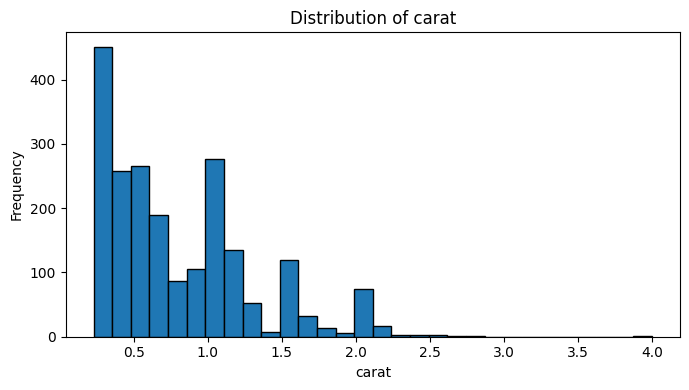

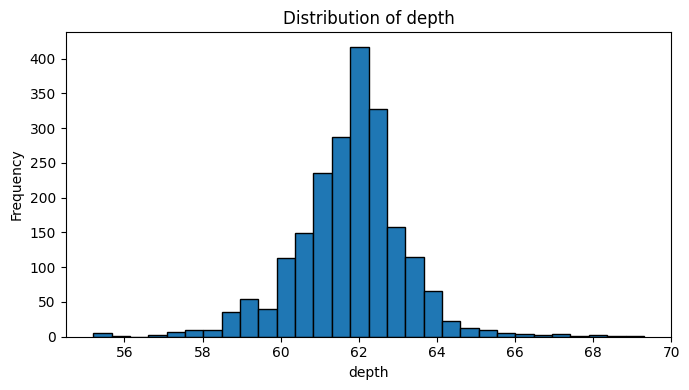

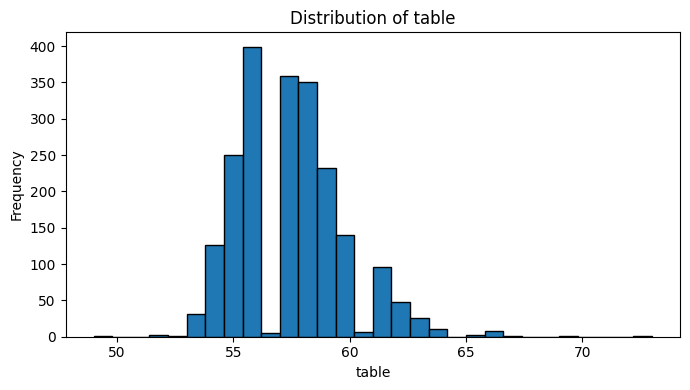

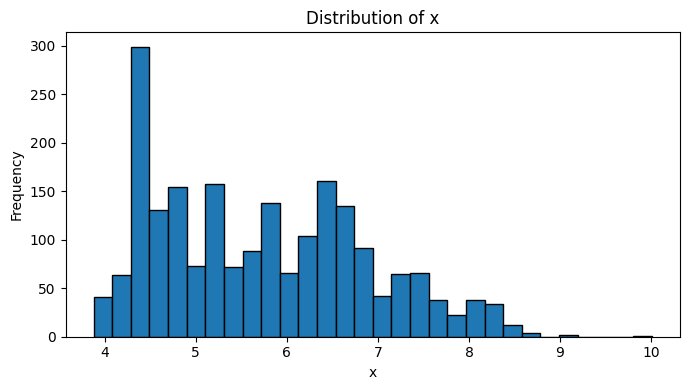

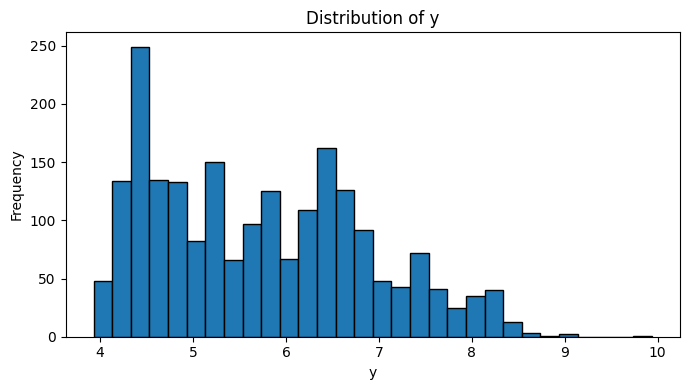

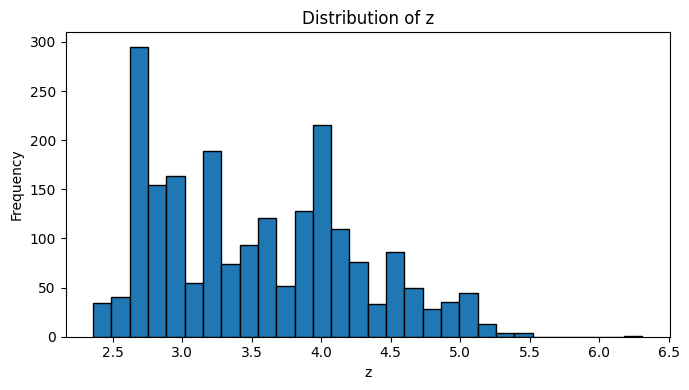

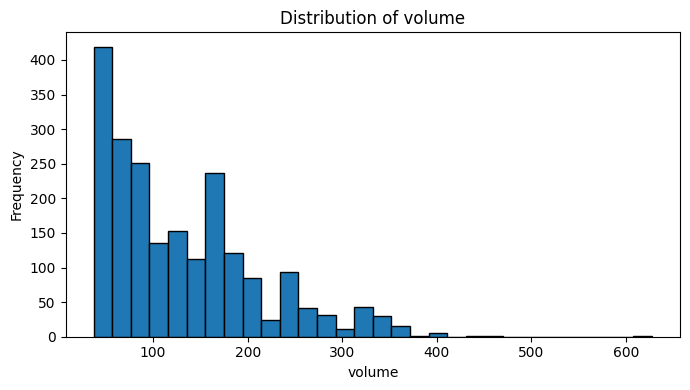

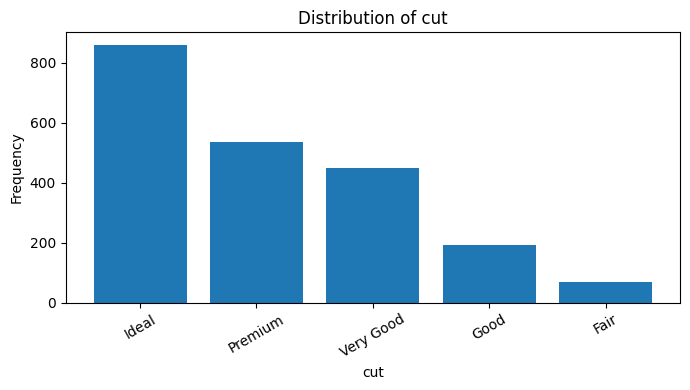

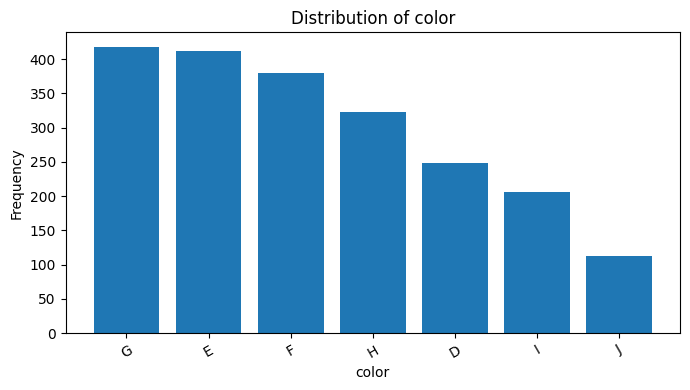

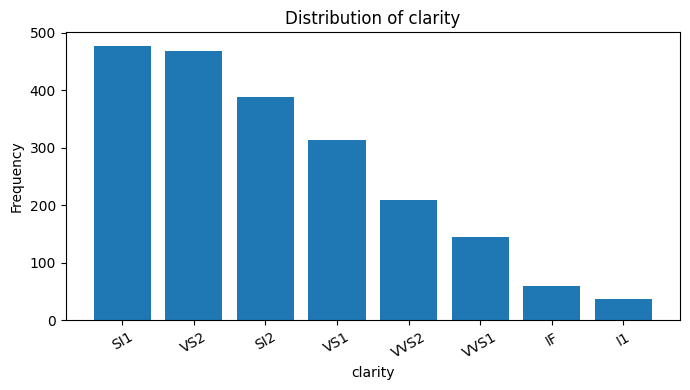

In [7]:
numeric_features=[c for c in df_clean.select_dtypes(include=np.number).columns if c!=TARGET]
categorical_features=df_clean.select_dtypes(include="object").columns.tolist()
for col in numeric_features:
    plt.figure(figsize=(7,4)); plt.hist(df_clean[col].dropna(),bins=30,edgecolor="black"); plt.title(f"Distribution of {col}"); plt.xlabel(col); plt.ylabel("Frequency"); plt.tight_layout(); plt.show()
for col in categorical_features:
    counts=df_clean[col].value_counts(); plt.figure(figsize=(7,4)); plt.bar(counts.index.astype(str),counts.values); plt.title(f"Distribution of {col}"); plt.xlabel(col); plt.ylabel("Frequency"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### A3 observation — student interpretation required

Describe notable skew, spread, tails, and category-frequency differences visible in the actual plots.

### 4.2 Correlation heatmap

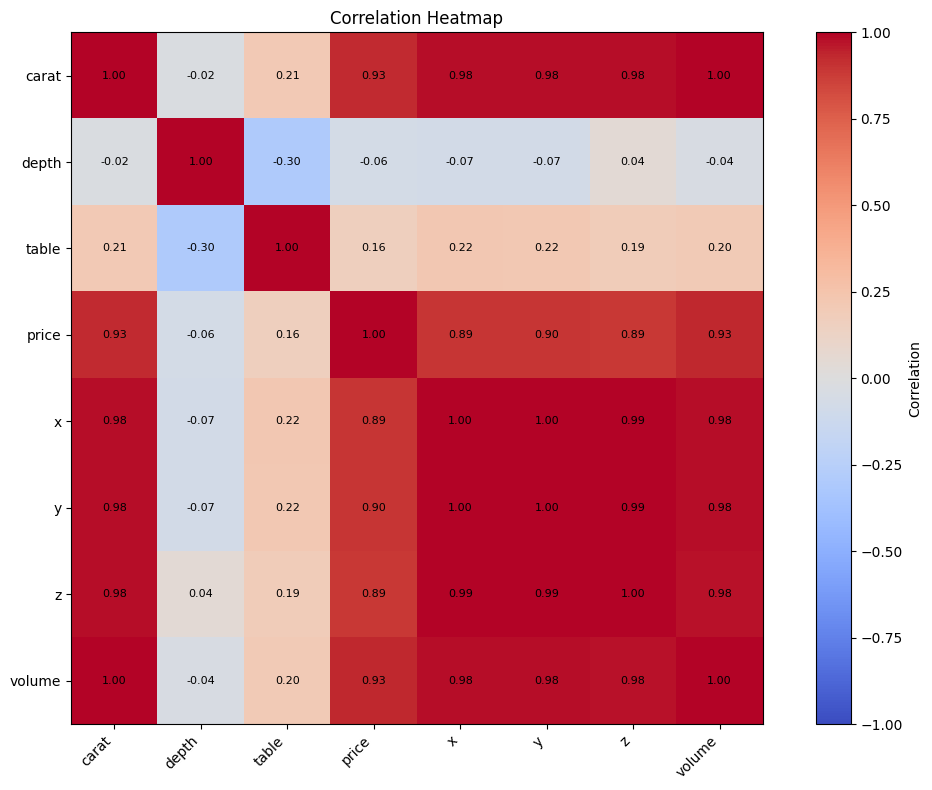

Correlation with price:


,Correlation with price
volume,0.931300
carat,0.929040
y,0.896134
x,0.893700
z,0.888481
table,0.161579
depth,-0.063104


In [8]:
corr=df_clean.select_dtypes(include=np.number).corr()
fig,ax=plt.subplots(figsize=(11,8)); im=ax.imshow(corr.values,cmap="coolwarm",vmin=-1,vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns,rotation=45,ha="right"); ax.set_yticklabels(corr.columns); fig.colorbar(im,ax=ax,label="Correlation"); ax.set_title("Correlation Heatmap")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)): ax.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=8)
plt.tight_layout(); plt.show()
print("Correlation with price:"); display(corr[TARGET].drop(TARGET).sort_values(key=np.abs,ascending=False).to_frame("Correlation with price"))

### A3 observation — student interpretation required

Identify the strongest relationships with `price` and potential multicollinearity among physical dimensions. Do not claim causation from correlation alone.

### 4.3 Target distribution

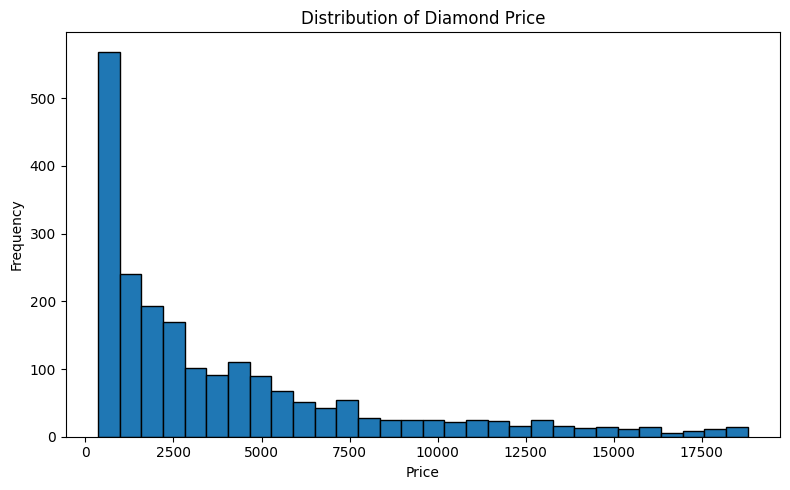

Mean price: 3969.03
Median price: 2322.00
Skewness: 1.6115


In [9]:
plt.figure(figsize=(8,5)); plt.hist(df_clean[TARGET],bins=30,edgecolor="black"); plt.title("Distribution of Diamond Price"); plt.xlabel("Price"); plt.ylabel("Frequency"); plt.tight_layout(); plt.show()
print(f"Mean price: {df_clean[TARGET].mean():.2f}"); print(f"Median price: {df_clean[TARGET].median():.2f}"); print(f"Skewness: {df_clean[TARGET].skew():.4f}")

### A3 observation — student interpretation required

Describe the shape of the price distribution and relate mean, median and skewness to the plot.

### 4.4 Feature-target relationships — at least two required

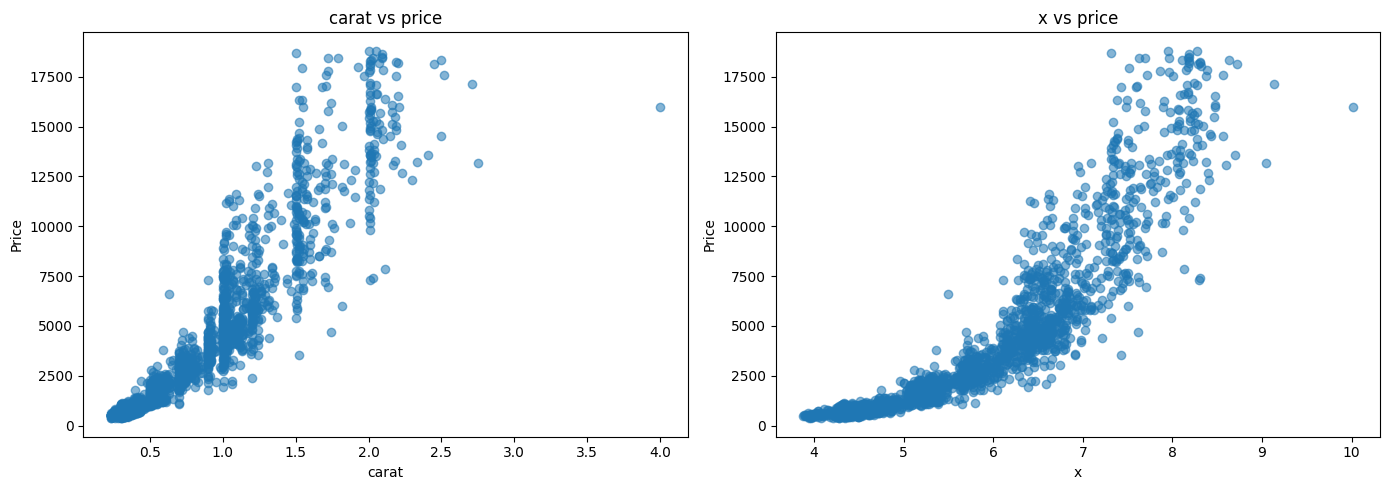

In [10]:
plot_features=["carat","x"]
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,feature in zip(axes,plot_features):
    ax.scatter(df_clean[feature],df_clean[TARGET],alpha=.55); ax.set_title(f"{feature} vs {TARGET}"); ax.set_xlabel(feature); ax.set_ylabel("Price")
plt.tight_layout(); plt.show()

### A3 observation — student interpretation required

For both plots, discuss direction, approximate linearity/nonlinearity, spread and visible extreme points.

## 5. Train/test split & leakage-safe preprocessing — B2

In [11]:
X=df_clean.drop(columns=[TARGET]); y=df_clean[TARGET]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=TEST_SIZE,random_state=RANDOM_STATE)
print("Train shape:",X_train.shape); print("Test shape:",X_test.shape)
all_numeric=X.select_dtypes(include=np.number).columns.tolist(); all_categorical=X.select_dtypes(include="object").columns.tolist()
numeric_transformer=Pipeline([("imputer",SimpleImputer(strategy="median")),("iqr_clip",IQRClipper()),("scaler",StandardScaler())])
categorical_transformer=Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
preprocessor=ColumnTransformer([("num",numeric_transformer,all_numeric),("cat",categorical_transformer,all_categorical)])
print("Numeric features:",all_numeric); print("Categorical features:",all_categorical)

Train shape: (1679, 10)
Test shape: (420, 10)
Numeric features: ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
Categorical features: ['cut', 'color', 'clarity']


### B2 note

All imputation, IQR clipping, scaling and encoding occur inside the model `Pipeline`, so they are fitted only on the relevant training data and not on the held-out test set.

## 6. Model training — Gradient Boosting Regression

Gradient Boosting Regression builds trees sequentially, with later trees focusing on errors made by earlier trees. The rubric specifically calls for tuning the learning rate.

In [12]:
model=GradientBoostingRegressor(random_state=RANDOM_STATE)
pipeline=Pipeline([("preprocessor",preprocessor),("model",model)])
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
r2=r2_score(y_test,y_pred); rmse=np.sqrt(mean_squared_error(y_test,y_pred)); mae=mean_absolute_error(y_test,y_pred)
print(f"Test R²: {r2:.4f}"); print(f"Test RMSE: {rmse:.4f}"); print(f"Test MAE: {mae:.4f}")

Test R²: 0.9610
Test RMSE: 821.1617
Test MAE: 454.6824


## 7. 5-fold cross-validated R²

In [13]:
cv=KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
cv_scores=cross_val_score(pipeline,X,y,cv=cv,scoring="r2",n_jobs=1)
print("5-fold CV R² scores:",np.round(cv_scores,4)); print(f"Mean CV R²: {cv_scores.mean():.4f}"); print(f"Std CV R²: {cv_scores.std():.4f}"); print(f"Held-out test R²: {r2:.4f}")

5-fold CV R² scores: [0.9612 0.9564 0.9573 0.9522 0.9692]
Mean CV R²: 0.9593
Std CV R²: 0.0057
Held-out test R²: 0.9610


### CV observation —

Gradient Boosting achieved R² = 0.9610, RMSE = 821.16, and MAE = 454.68. Mean 5-fold CV R² is 0.9593 with standard deviation 0.0057, indicating strong and stable performance.

## 8. Hyperparameter tuning — Review 1 C3 contribution

In [14]:
param_distributions = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "model__max_depth": [2, 3, 4]
}

search = RandomizedSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]),
    param_distributions,
    n_iter=6,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=1
)

search.fit(X_train, y_train)
tuned_pred = search.predict(X_test)
tuned_r2 = r2_score(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_mae = mean_absolute_error(y_test, tuned_pred)

print("Best parameters:", search.best_params_)
print(f"Best CV R²: {search.best_score_:.4f}")
print(f"Tuned Test R²: {tuned_r2:.4f}")
print(f"Tuned Test RMSE: {tuned_rmse:.4f}")
print(f"Tuned Test MAE: {tuned_mae:.4f}")
print(f"R² improvement: {tuned_r2 - r2:+.4f}")

Best parameters: {'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.15}
Best CV R²: 0.9581
Tuned Test R²: 0.9663
Tuned Test RMSE: 762.9409
Tuned Test MAE: 416.4928
R² improvement: +0.0053


### Algorithm-specific observation — Gradient Boosting Regression
The selected configuration is n_estimators = 150, max_depth = 3, and learning_rate = 0.15. The tuned test R² increases to 0.9663, an improvement of about 0.0053. RMSE falls from 821.16 to 762.94, and MAE falls from 454.68 to 416.49. This is a clear example where tuning improves both fit and error measures.


### Gradient Boosting feature importance — tree-model analysis

,Feature,Importance
4,num__y,0.418253
6,num__volume,0.407458
5,num__z,0.056718
0,num__carat,0.030586
3,num__x,0.026578
22,cat__clarity_SI2,0.013063
19,cat__clarity_I1,0.009079
18,cat__color_J,0.007878
26,cat__clarity_VVS2,0.006451
17,cat__color_I,0.005276


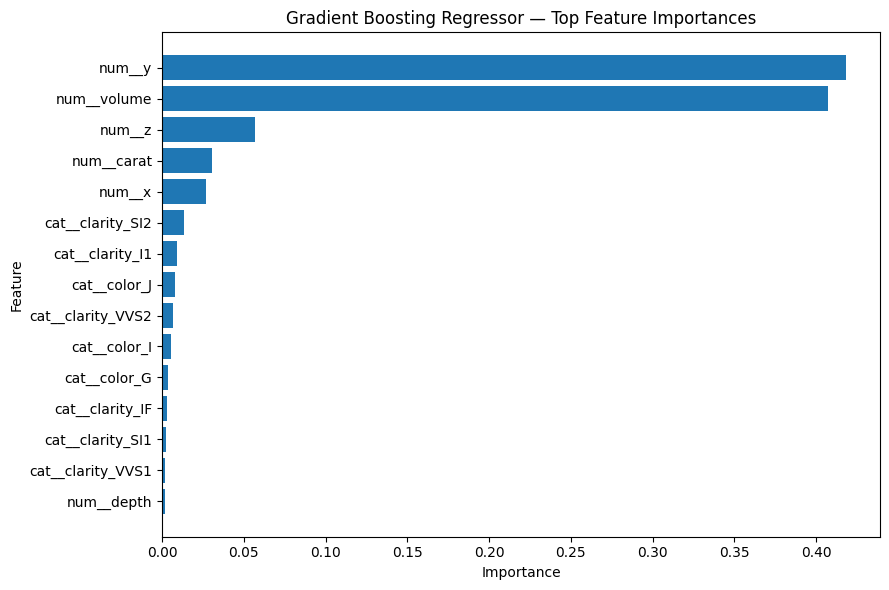

In [15]:
gb_model = pipeline.named_steps["model"]
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": gb_model.feature_importances_}).sort_values("Importance", ascending=False)
display(importance_df.head(15))
plt.figure(figsize=(9, 6))
top_imp = importance_df.head(15).sort_values("Importance")
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.title("Gradient Boosting Regressor — Top Feature Importances")
plt.xlabel("Importance"); plt.ylabel("Feature"); plt.tight_layout(); plt.show()

Compare dominant Gradient Boosting features with the correlation heatmap and discuss any notable differences.

## 9. Diagnostic visualisations — C4 contribution

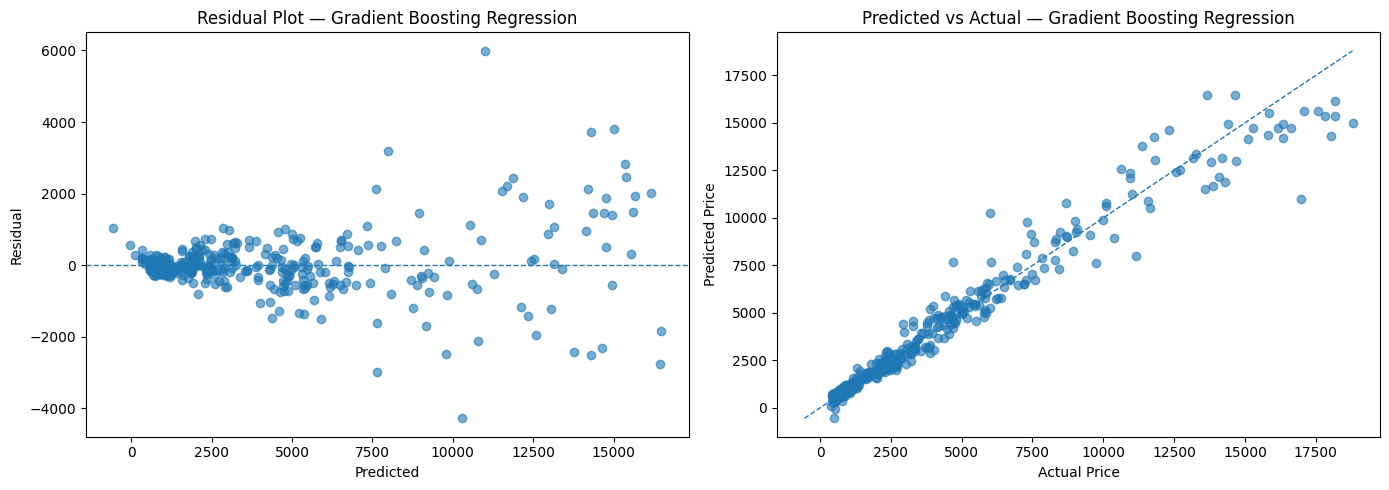

In [16]:
diagnostic_pred=y_pred; residuals=y_test-diagnostic_pred
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(diagnostic_pred,residuals,alpha=.6); axes[0].axhline(0,linestyle="--",linewidth=1); axes[0].set_title("Residual Plot — Gradient Boosting Regression"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[1].scatter(y_test,diagnostic_pred,alpha=.6); lims=[min(y_test.min(),diagnostic_pred.min()),max(y_test.max(),diagnostic_pred.max())]; axes[1].plot(lims,lims,linestyle="--",linewidth=1); axes[1].set_title("Predicted vs Actual — Gradient Boosting Regression"); axes[1].set_xlabel("Actual Price"); axes[1].set_ylabel("Predicted Price")
plt.tight_layout(); plt.show()

### Diagnostic observation — student interpretation required
The tuned boosting model should show a tighter predicted-vs-actual relationship and lower residual magnitudes than the untuned model. Examine whether residual spread remains larger for expensive diamonds.

## 10. Save model and machine-readable result row

In [17]:
PROJECT_ROOT=Path("..") if Path("../data").exists() else Path("/mnt/data")
RESULTS_DIR=PROJECT_ROOT/"results"; MODELS_DIR=PROJECT_ROOT/"models"; RESULTS_DIR.mkdir(parents=True,exist_ok=True); MODELS_DIR.mkdir(parents=True,exist_ok=True)
joblib.dump(pipeline,MODELS_DIR/"gradient_boosting_regression_baseline.joblib")
result_row=pd.DataFrame([{"Model":"Gradient Boosting Regression","R2":r2,"RMSE":rmse,"MAE":mae,"CV_R2_Mean":cv_scores.mean(),"CV_R2_Std":cv_scores.std(),"Tuned_R2":tuned_r2,"Tuned_RMSE":tuned_rmse,"Tuned_MAE":tuned_mae}])
result_row.to_csv(RESULTS_DIR/"regression_gradient_boosting_results.csv",index=False)
display(result_row)

,Model,R2,RMSE,MAE,CV_R2_Mean,CV_R2_Std,Tuned_R2,Tuned_RMSE,Tuned_MAE
0,Gradient Boosting Regression,0.960959,821.161713,454.682367,0.959271,0.005728,0.966299,762.94087,416.492805
